# Experiment 4: validation robustness

Experiment 3 found a +0.0090 accuracy advantage for `GradientBoostingClassifier` on the seed-42 split. This notebook tests whether that advantage persists across validation splits. Features and model hyperparameters remain unchanged, and the Kaggle leaderboard is not used.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
SEEDS = list(range(19)) + [42]  # 20 distinct, predetermined seeds; includes Experiment 3
N_BOOTSTRAP = 20_000
ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
train = pd.read_csv(ROOT / 'data' / 'raw' / 'train.csv')
X_raw = train.drop(columns='Survived')
y = train['Survived']
print(f'{len(SEEDS)} seeds × 5 folds = {len(SEEDS) * 5} paired fold comparisons')

Matplotlib is building the font cache; this may take a moment.


20 seeds × 5 folds = 100 paired fold comparisons


## Fixed feature set and models

The feature set is exactly Experiment 2: numeric `Age`, `SibSp`, `Parch`, and `Fare`; categorical `Pclass`, `Sex`, and `Embarked`; plus engineered `Title` and `IsAlone`. No feature or hyperparameter changes are made. Learned imputation, encoding, and scaling remain inside each fold's pipeline to prevent leakage. Logistic regression uses scaling; gradient boosting does not need it.

In [2]:
NUMERIC = ['Age', 'SibSp', 'Parch', 'Fare']
CATEGORICAL = ['Pclass', 'Sex', 'Embarked', 'Title', 'IsAlone']
COMMON_TITLES = {'Mr', 'Miss', 'Mrs', 'Master'}

def engineer_features(df):
    df = df.copy()
    title = df['Name'].str.extract(r',\s*([^.]*)\.', expand=False).str.strip()
    df['Title'] = title.where(title.isin(COMMON_TITLES), 'Rare')
    df['IsAlone'] = ((df['SibSp'] + df['Parch']) == 0).astype(int)
    return df

X = engineer_features(X_raw)

def make_pipeline(model_name):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if model_name == 'LogisticRegression':
        numeric_steps.append(('scaler', StandardScaler()))
        estimator = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
    else:
        estimator = GradientBoostingClassifier(random_state=RANDOM_STATE)
    preprocessing = ColumnTransformer([
        ('numeric', Pipeline(numeric_steps), NUMERIC),
        ('categorical', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), CATEGORICAL),
    ])
    return Pipeline([('preprocessing', preprocessing), ('model', estimator)])

## Repeated paired stratified validation

For every seed, one `StratifiedKFold` object generates five folds that are reused identically for both models. The long-form table preserves every fold score; the seed summary records both five-fold means and their paired difference.

In [3]:
fold_rows = []
for seed in SEEDS:
    splits = list(StratifiedKFold(n_splits=5, shuffle=True, random_state=seed).split(X, y))
    for fold, (train_idx, valid_idx) in enumerate(splits, 1):
        scores = {}
        for model_name in ('LogisticRegression', 'GradientBoostingClassifier'):
            model = make_pipeline(model_name)
            model.fit(X.iloc[train_idx], y.iloc[train_idx])
            scores[model_name] = accuracy_score(y.iloc[valid_idx], model.predict(X.iloc[valid_idx]))
        fold_rows.append({
            'Seed': seed, 'Fold': fold,
            'LogisticRegression': scores['LogisticRegression'],
            'GradientBoostingClassifier': scores['GradientBoostingClassifier'],
            'PairedDifference': scores['GradientBoostingClassifier'] - scores['LogisticRegression'],
        })
fold_results = pd.DataFrame(fold_rows)
seed_results = (fold_results.groupby('Seed', sort=False)
                [['LogisticRegression', 'GradientBoostingClassifier']].mean())
seed_results['PairedDifference'] = (seed_results['GradientBoostingClassifier']
                                    - seed_results['LogisticRegression'])
assert len(fold_results) == 100 and len(seed_results) == 20
display(fold_results.style.format({
    'LogisticRegression': '{:.4f}', 'GradientBoostingClassifier': '{:.4f}',
    'PairedDifference': '{:+.4f}'
}))
display(seed_results.style.format({
    'LogisticRegression': '{:.4f}', 'GradientBoostingClassifier': '{:.4f}',
    'PairedDifference': '{:+.4f}'
}))

,Seed,Fold,LogisticRegression,GradientBoostingClassifier,PairedDifference
0,0,1,0.8436,0.8715,+0.0279
1,0,2,0.8708,0.8652,-0.0056
2,0,3,0.8315,0.8258,-0.0056
3,0,4,0.7865,0.7978,+0.0112
4,0,5,0.8034,0.8146,+0.0112
5,1,1,0.8156,0.8156,+0.0000
6,1,2,0.8427,0.8371,-0.0056
7,1,3,0.8146,0.8146,+0.0000
8,1,4,0.7978,0.8371,+0.0393
9,1,5,0.8596,0.8483,-0.0112


,LogisticRegression,GradientBoostingClassifier,PairedDifference
Seed,,,
0,0.8271,0.8350,+0.0078
1,0.8260,0.8305,+0.0045
2,0.8249,0.8316,+0.0068
3,0.8316,0.8350,+0.0034
4,0.8249,0.8193,-0.0056
5,0.8283,0.8227,-0.0057
6,0.8238,0.8294,+0.0057
7,0.8238,0.8395,+0.0157
8,0.8261,0.8328,+0.0067


## Paired summary and confidence interval

The primary comparison unit is the seed-level five-fold mean difference. Bootstrapping these 20 paired seed differences preserves pairing and quantifies sensitivity to the chosen splits. It is more appropriate here than treating 100 overlapping test folds as independent. The percentile interval is descriptive rather than a formal population guarantee because observations are repeatedly reused across seeds.

In [4]:
differences = seed_results['PairedDifference'].to_numpy()
rng = np.random.default_rng(RANDOM_STATE)
bootstrap_means = differences[rng.integers(0, len(differences),
                                           size=(N_BOOTSTRAP, len(differences)))].mean(axis=1)
ci_low, ci_high = np.quantile(bootstrap_means, [0.025, 0.975])
wins = int((differences > 0).sum())
ties = int(np.isclose(differences, 0, atol=1e-12).sum())
losses = int((differences < 0).sum())
summary = pd.DataFrame({
    'Statistic': [
        'Logistic overall fold accuracy', 'GradientBoosting overall fold accuracy',
        'Mean paired seed difference', 'Median paired seed difference',
        '95% paired seed-bootstrap CI', 'GradientBoosting seed wins',
        'Seed ties', 'Seed losses', 'Seed-42 paired difference'
    ],
    'Result': [
        f"{fold_results['LogisticRegression'].mean():.4f} ± {fold_results['LogisticRegression'].std(ddof=0):.4f}",
        f"{fold_results['GradientBoostingClassifier'].mean():.4f} ± {fold_results['GradientBoostingClassifier'].std(ddof=0):.4f}",
        f'{differences.mean():+.4f}', f'{np.median(differences):+.4f}',
        f'[{ci_low:+.4f}, {ci_high:+.4f}]', f'{wins}/{len(differences)} ({wins/len(differences):.0%})',
        f'{ties}/{len(differences)} ({ties/len(differences):.0%})',
        f'{losses}/{len(differences)} ({losses/len(differences):.0%})',
        f"{seed_results.loc[42, 'PairedDifference']:+.4f}",
    ]
})
display(summary)

,Statistic,Result
0,Logistic overall fold accuracy,0.8269 ± 0.0264
1,GradientBoosting overall fold accuracy,0.8325 ± 0.0250
2,Mean paired seed difference,+0.0056
3,Median paired seed difference,+0.0062
4,95% paired seed-bootstrap CI,"[+0.0031, +0.0078]"
5,GradientBoosting seed wins,17/20 (85%)
6,Seed ties,0/20 (0%)
7,Seed losses,3/20 (15%)
8,Seed-42 paired difference,+0.0090


## Validation distributions

The left panel compares the 20 seed-level mean accuracies. The center panel shows the paired difference distribution and its bootstrap interval. The right panel preserves the pairing explicitly: points above the diagonal favor gradient boosting.

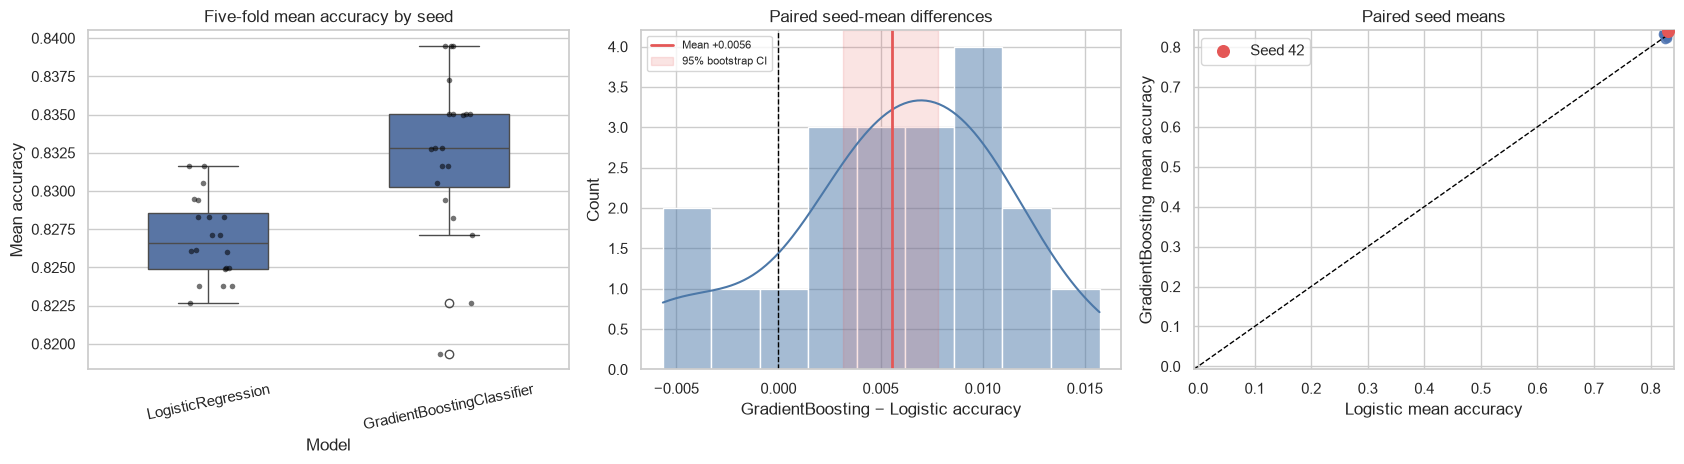

In [5]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
long_seed = (seed_results.reset_index().melt(
    id_vars='Seed', value_vars=['LogisticRegression', 'GradientBoostingClassifier'],
    var_name='Model', value_name='Mean accuracy'))
sns.boxplot(data=long_seed, x='Model', y='Mean accuracy', ax=axes[0], width=.5)
sns.stripplot(data=long_seed, x='Model', y='Mean accuracy', ax=axes[0], color='black', alpha=.55, size=4)
axes[0].set_title('Five-fold mean accuracy by seed')
axes[0].tick_params(axis='x', rotation=12)

sns.histplot(differences, bins=9, kde=True, ax=axes[1], color='#4C78A8')
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].axvline(differences.mean(), color='#E45756', linewidth=2, label=f'Mean {differences.mean():+.4f}')
axes[1].axvspan(ci_low, ci_high, color='#E45756', alpha=.16, label='95% bootstrap CI')
axes[1].set_title('Paired seed-mean differences')
axes[1].set_xlabel('GradientBoosting − Logistic accuracy')
axes[1].legend(fontsize=8)

axes[2].scatter(seed_results['LogisticRegression'], seed_results['GradientBoostingClassifier'], alpha=.75)
lo = min(seed_results.min()) - .002
hi = max(seed_results.max()) + .002
axes[2].plot([lo, hi], [lo, hi], '--', color='black', linewidth=1)
seed42 = seed_results.loc[42]
axes[2].scatter(seed42['LogisticRegression'], seed42['GradientBoostingClassifier'],
                color='#E45756', s=70, label='Seed 42', zorder=3)
axes[2].set(xlim=(lo, hi), ylim=(lo, hi), xlabel='Logistic mean accuracy',
            ylabel='GradientBoosting mean accuracy', title='Paired seed means')
axes[2].legend()
plt.tight_layout()
plt.show()

## Conclusion

The original +0.0090 seed-42 advantage is somewhat favorable relative to the multi-seed average, so its exact magnitude is split-sensitive. The direction is nevertheless stable: gradient boosting wins 17 of 20 seeds, and the paired seed-bootstrap interval remains above zero. Across all 100 folds, its mean accuracy is also higher with slightly lower fold-level dispersion.

Therefore, the evidence supports retaining `GradientBoostingClassifier` as the current champion. The expected advantage is better characterized as roughly +0.0056 than +0.0090, and it should still be treated as modest rather than definitive. No new model was introduced, so this robustness analysis creates no new submission.